In [460]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import expon, skew, norm, probplot
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

plt.rcParams['figure.figsize'] = [15, 7]
import warnings

warnings.filterwarnings('ignore')

In [461]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c':
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'max2':
            arr += [x[-1] + x[-2]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # index knn and the distance of each value
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="max")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr)) #normalize the values
        means = np.mean(arr) # exp function mean value
        inMean = 1 / means
        posNeg4 = []
        params = expon.fit(arr)
        skewed = stats.skewnorm.fit(arr)
        #print(skewed)
        spaceStep4 = np.linspace(0,.99,30) # perform steps from .95 to .99
        for e in spaceStep4:
            #ker = -means * np.log(1 - e) # the percentile
            #f = integrate.quad(lambda x: inMean * np.exp(-x * inMean), 0, ker)
            #newArr = arr > ker # return a new array of values bigger than the percentile
            #newArr = arr > expon.ppf(e,loc=params[0],scale=params[1])
            newArr = arr > stats.skewnorm.ppf(e,skewed[0],loc=skewed[1],scale=skewed[2])
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def goodnessOfFit(X,y,kValue):
    knn, distReturn = main(X, y, kValue) # return knn and distance
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax") #
    print(skew(arr)) # check for skewness
    params = expon.fit(arr) # fit the arr generated and get the params
    test = np.linspace(min(arr),max(arr),10)
    # pdfTest = expon.pdf(test,params[0],params[1]) #line used to test the pdf form

    values, edges = np.histogram(arr, bins=int(np.sqrt(len(arr))), density=True) #get values from bins and the edges
    #print(values, edges)
    newX = edges[:-1] + np.diff(edges) # X values from the bins

    pdf_fitted = expon.pdf(newX, loc=params[0], scale=params[1]) # generate a new pdf using the new X values
    residuals = values - pdf_fitted # values vs the generated pdf
    print(pdf_fitted)
    #print(np.dot(residuals, residuals))
    print(sum(pow(residuals, 2) / pdf_fitted)) # prints the chi squared value
    plt.scatter(edges[:-1], values)
    plt.scatter(edges[:-1], pdf_fitted)
    plt.show()

def ksTestArr(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="max")
    params = expon.fit(arr)
    results = stats.kstest(arr, expon.cdf,args=(params[0],params[1]))
    print(f"Loc: {params[0]}, scale: {params[1]}")
    print(f"stats: {results[0]}, p-value:{results[1]}")
    plt.hist(arr,bins=50)
    plt.title(name)
    plt.show()

def ksTestNorm(X,y,kValue):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = stats.skewnorm.fit(arr)
    results = stats.kstest(arr, stats.skewnorm.cdf,args=(params[0],params[1],params[2]))
    print(f"stats: {results[0]}, p-value:{results[1]}")

def qqPlots(X,y,kValue, name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="max")
    params = stats.skewnorm.fit(arr)
    results = probplot(arr,dist=stats.skewnorm, plot=plt,sparams=(params[0],params[1],params[2]),rvalue=True)
    plt.title(name)
    plt.show()

0.7620265000795797 45 [0.7432158204679294, 0.7512036447556899, 0.7483686137195606, 0.749920420181442, 0.7519497055546712, 0.753879516154703, 0.7568239694413497, 0.7570726563743435, 0.7556999045042176, 0.7546156294763647, 0.7544166799299697, 0.7536009867897501, 0.7572318160114594, 0.7592511539073691, 0.7583260385166322, 0.7588731497692184, 0.7590720993156135, 0.7579281394238421, 0.7565255451217572, 0.7555506923444214, 0.7539690434505809, 0.7553119528887474, 0.7557993792774151, 0.7550334235237943, 0.7548145790227597, 0.7560679611650485, 0.7561674359382461, 0.7584155658125099, 0.7579480343784816, 0.7584056183351902, 0.7572815533980581, 0.7583956708578704, 0.7598778449785134, 0.7589825720197357, 0.7592611013846888, 0.7609521725290465, 0.7597286328187172, 0.7604249562310997, 0.7596987903867578, 0.7601464268661468, 0.7604448511857393, 0.7600767945249085, 0.7609322775744072, 0.7620265000795797, 0.7593406812032468, 0.7588731497692185, 0.7596987903867579, 0.7589129396784975, 0.758574725449626, 

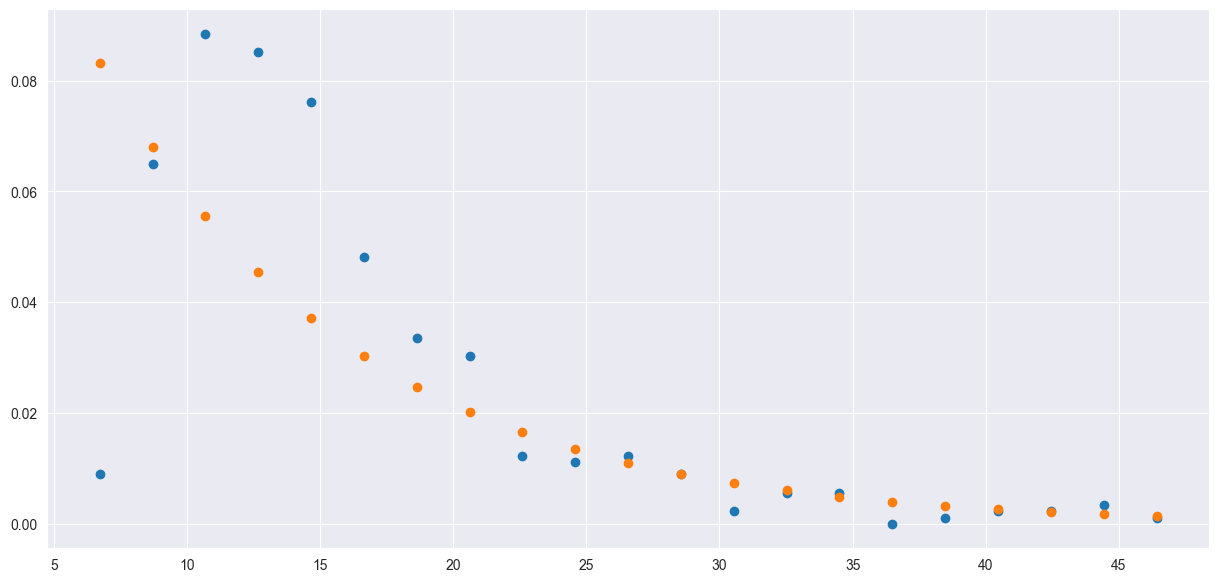

Loc: 4.482397398254796, scale: 6.547621360022393
stats: 0.2204755794098957, p-value:1.0849084662533221e-19


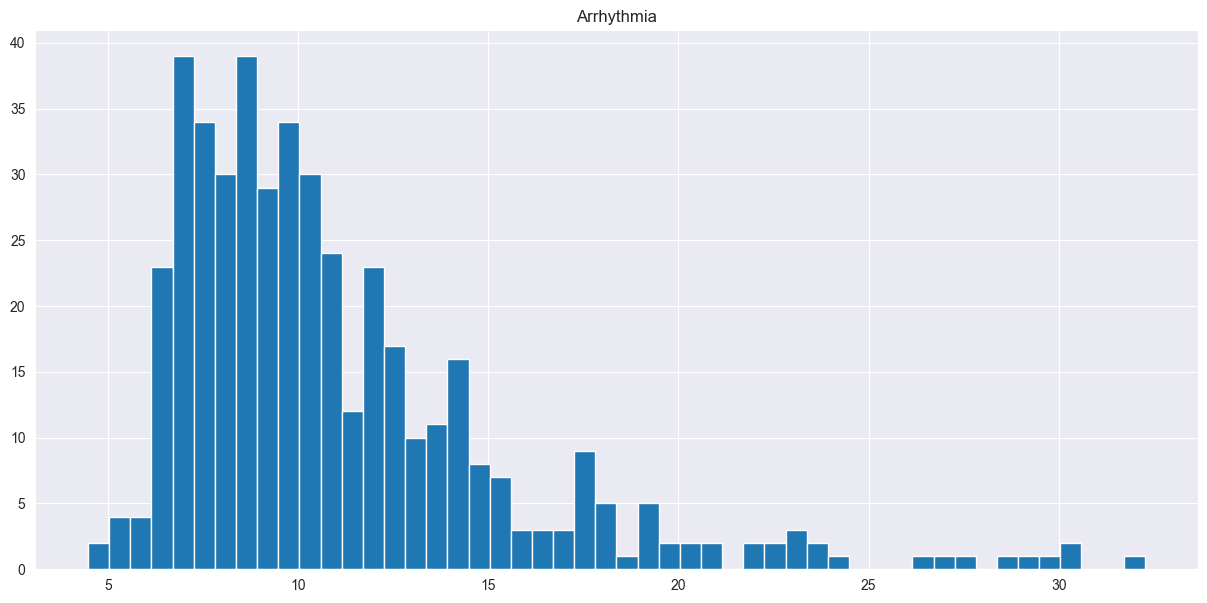

stats: 0.10039804269481167, p-value:0.00021141308961777463


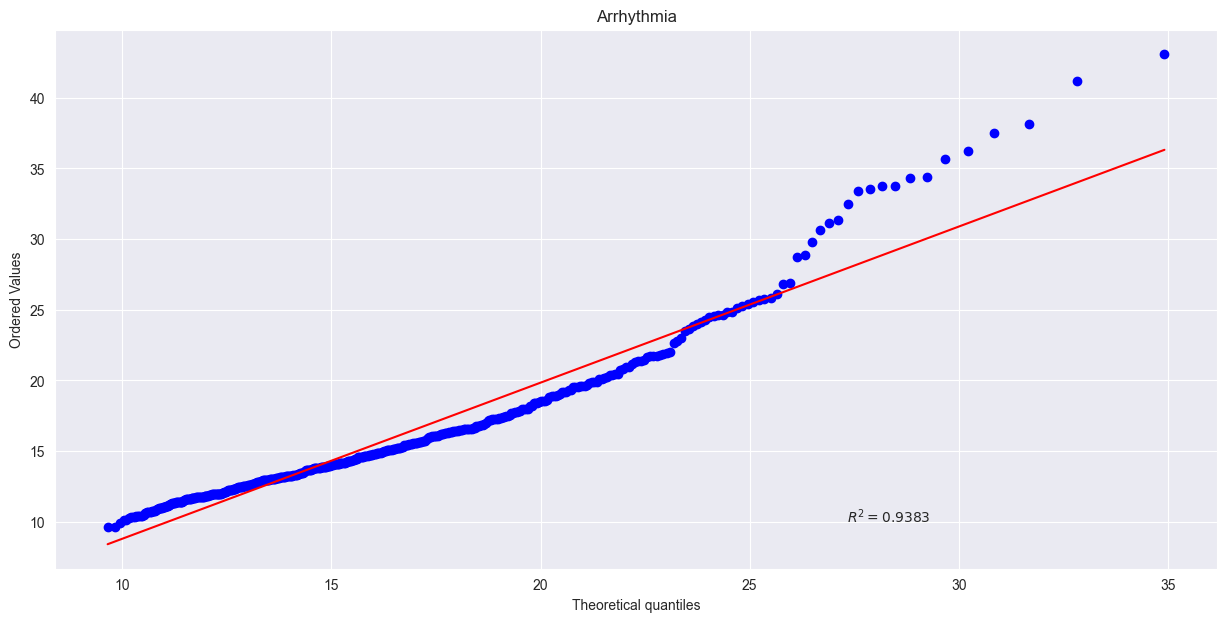

In [462]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)
ksTestArr(X,y,2, "Arrhythmia")
ksTestNorm(X,y,2)
qqPlots(X,y,45,"Arrhythmia")

0.7396541950113379 6 [0.6511479591836735, 0.6963577097505669, 0.7376700680272109, 0.7172619047619048, 0.7396541950113379, 0.6918934240362812, 0.6831774376417235, 0.6803429705215419, 0.6561791383219955, 0.6478174603174603, 0.6446286848072562, 0.6394557823129252, 0.6287556689342404, 0.6067885487528344, 0.5982142857142858, 0.5935374149659863, 0.5792233560090703, 0.5845379818594105, 0.5780187074829932, 0.5768140589569161, 0.5710742630385487, 0.5705073696145124, 0.5717120181405896, 0.5688066893424036, 0.5695153061224489, 0.5608701814058957, 0.559311224489796, 0.5610827664399093, 0.5573270975056689, 0.5556972789115646, 0.5538548752834467, 0.5520124716553287, 0.5541383219954648, 0.5520833333333334, 0.5542091836734695, 0.5539965986394558, 0.5511621315192744, 0.5511621315192744, 0.551374716553288, 0.5512329931972789, 0.548611111111111, 0.5425170068027211, 0.53734410430839, 0.534155328798186, 0.5306122448979591, 0.5348639455782314, 0.5346513605442176, 0.5291950113378685, 0.5242346938775511, 0.51

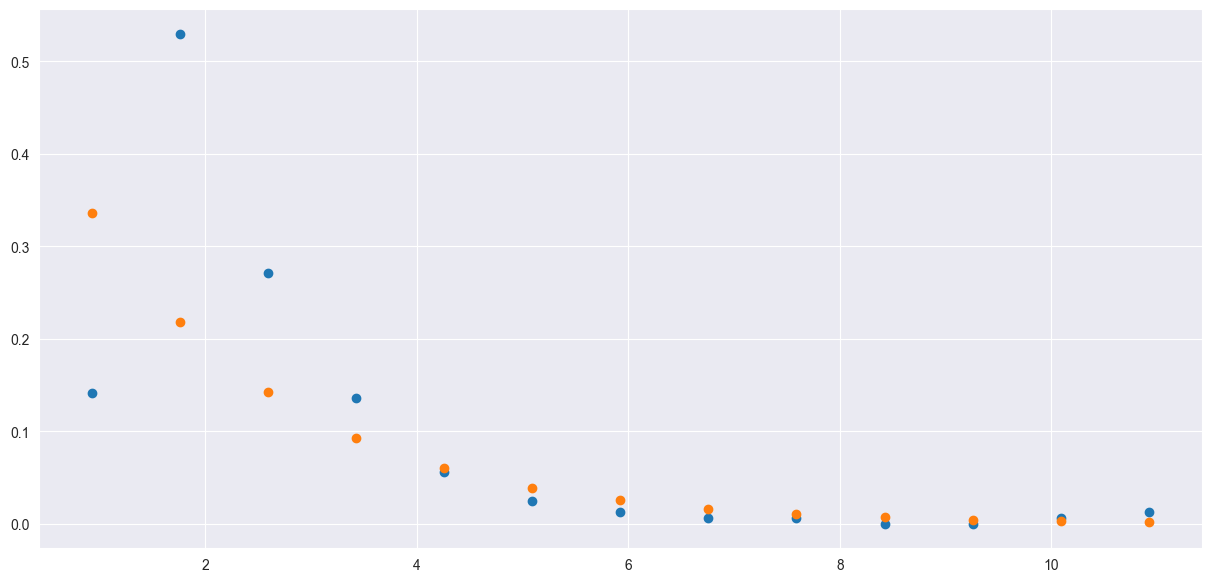

Loc: 0.18576929856018978, scale: 0.7767144985824351
stats: 0.23096223349528383, p-value:1.2542122727157265e-09


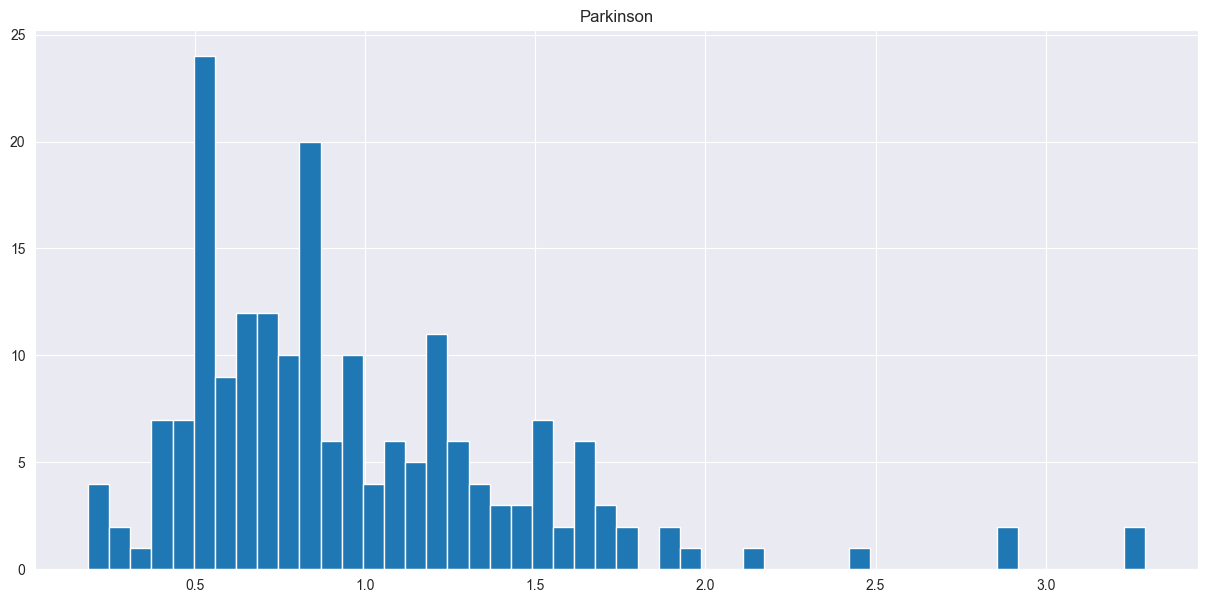

stats: 0.08279721889792807, p-value:0.13041545598181303


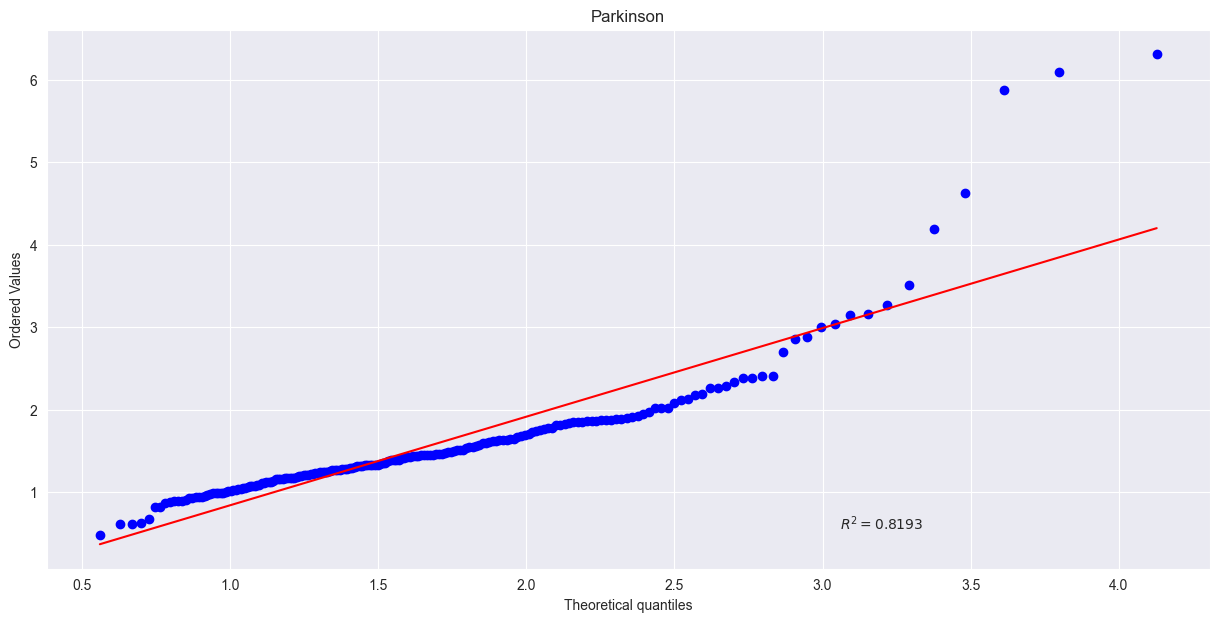

In [463]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,6)
ksTestArr(X,y,2,"Parkinson")
ksTestNorm(X,y,2)
qqPlots(X,y,6,"Parkinson")

0.8456153846153847 5 [0.31684615384615394, 0.4550769230769231, 0.6190769230769232, 0.8456153846153847, 0.8419615384615384, 0.8177307692307693, 0.8128461538461538, 0.7947692307692308, 0.7964999999999999, 0.7932307692307692, 0.7832692307692307, 0.7768846153846154, 0.7807692307692309, 0.7767692307692309, 0.7685, 0.7679230769230769, 0.7636538461538462, 0.7553846153846154, 0.7585384615384617, 0.7555, 0.7558076923076925, 0.7576923076923077, 0.7525769230769229, 0.7472307692307691, 0.7481923076923076, 0.7460000000000001, 0.7423846153846153, 0.7412692307692308, 0.7439615384615383, 0.7377307692307691, 0.7398461538461537, 0.7387307692307691, 0.737, 0.7349230769230769, 0.7265384615384615, 0.7271923076923077, 0.7295384615384615, 0.7331538461538462, 0.7322692307692309, 0.732923076923077, 0.7268846153846155, 0.7250384615384616, 0.7197692307692309, 0.718923076923077, 0.713269230769231, 0.7131153846153847, 0.7129615384615384, 0.7105, 0.7113846153846154, 0.7105384615384617, 0.7041538461538464, 0.7041538

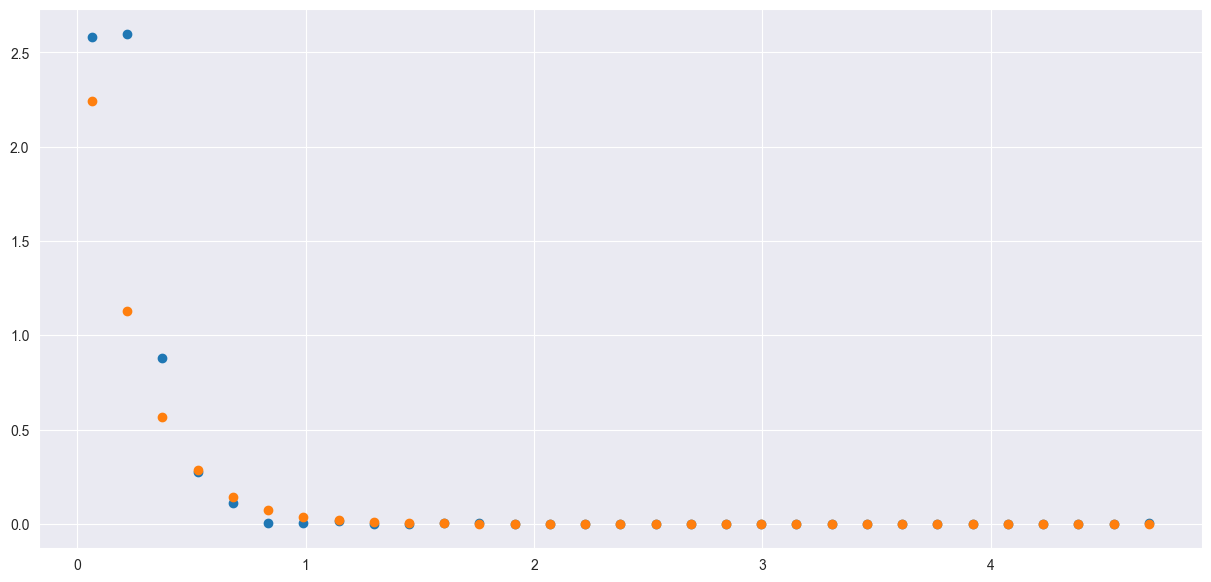

Loc: 0.04054079590518085, scale: 0.12511317817411427
stats: 0.1715731229711463, p-value:1.524693118236842e-26


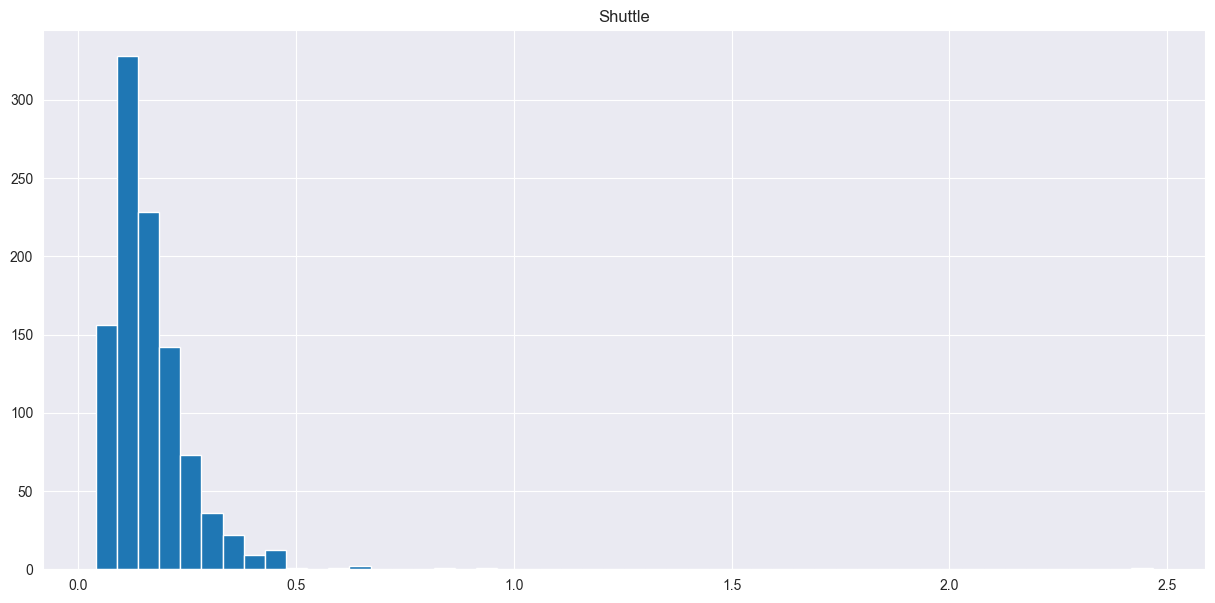

stats: 0.1334049626673891, p-value:3.499483379809721e-16


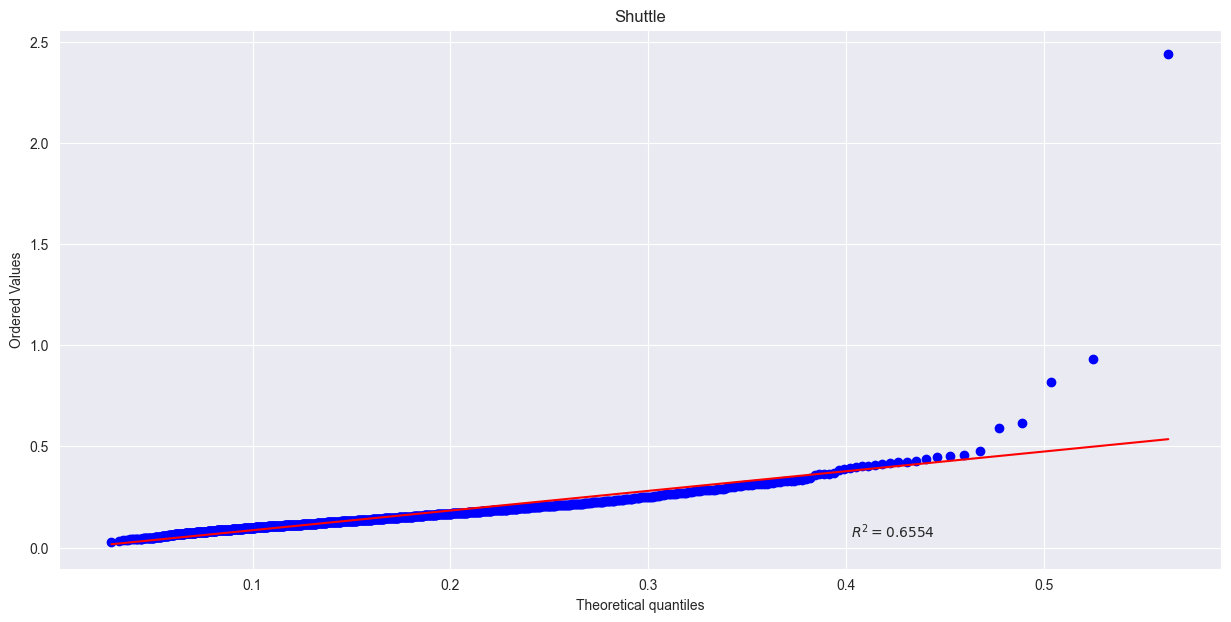

In [464]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,6)
ksTestArr(X,y,6,"Shuttle")
ksTestNorm(X,y,6)
qqPlots(X,y,5,"Shuttle")

0.9924882629107981 61 [0.966431924882629, 0.9849765258215961, 0.9842723004694834, 0.9915492957746478, 0.9910798122065727, 0.9835680751173709, 0.9800469483568076, 0.9802816901408451, 0.9800469483568073, 0.9845070422535209, 0.9892018779342723, 0.9892018779342723, 0.9896713615023474, 0.9894366197183099, 0.9894366197183098, 0.9894366197183098, 0.9896713615023472, 0.9896713615023474, 0.9896713615023475, 0.9896713615023476, 0.9896713615023475, 0.9896713615023475, 0.9896713615023475, 0.9896713615023474, 0.9896713615023475, 0.9896713615023474, 0.992488262910798, 0.992488262910798, 0.9882629107981219, 0.9882629107981219, 0.988262910798122, 0.988262910798122, 0.988262910798122, 0.988262910798122, 0.9896713615023475, 0.9896713615023475, 0.988262910798122, 0.988262910798122, 0.988262910798122, 0.9882629107981219, 0.988262910798122, 0.9882629107981219, 0.988262910798122, 0.988262910798122, 0.988262910798122, 0.988262910798122, 0.9896713615023475, 0.9896713615023475, 0.9896713615023475, 0.9896713615

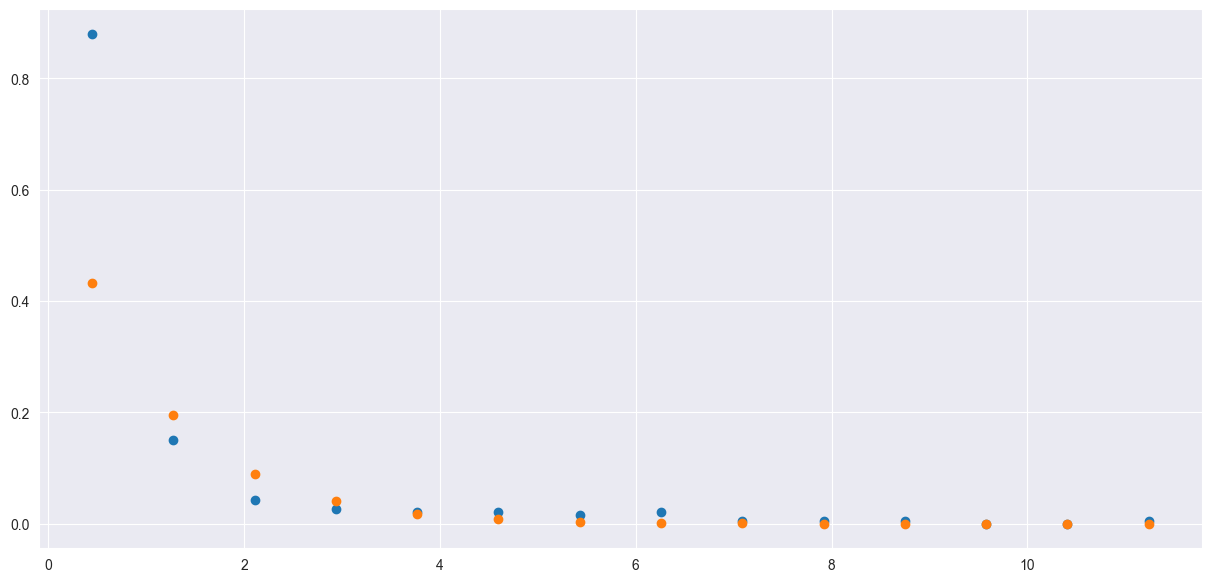

Loc: 0.2222222222222222, scale: 0.5909317389138019
stats: 0.21576650663928232, p-value:1.3604984022680067e-09


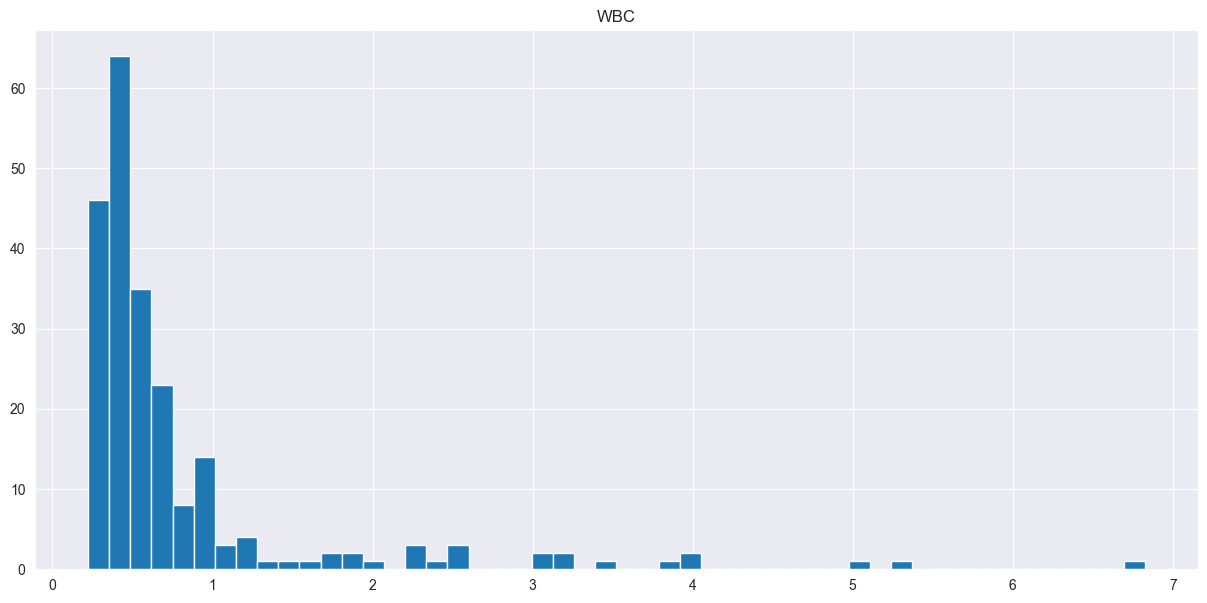

stats: 0.4233708292602075, p-value:9.059065480520973e-37


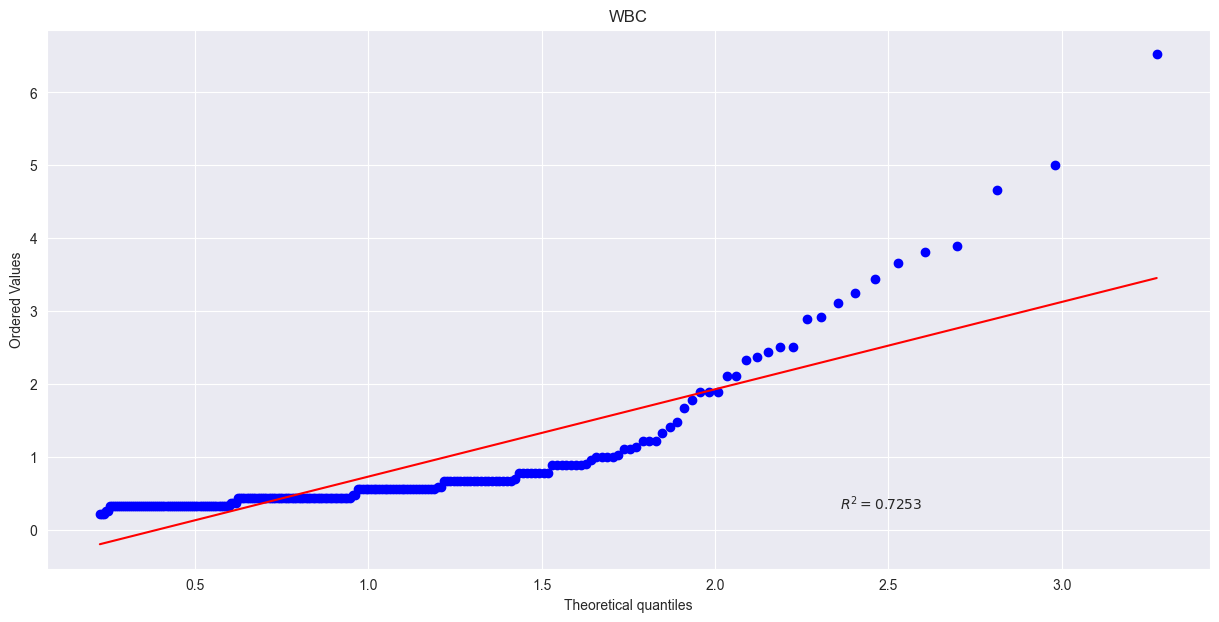

In [465]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,32)
ksTestArr(X,y,32,"WBC")
ksTestNorm(X,y,32)
qqPlots(X,y,27,"WBC")

0.6507493676540436 41 [0.40884535136194694, 0.4742468627724459, 0.508820095219427, 0.53079199681848, 0.5467887710059484, 0.5705301339706427, 0.585891970619944, 0.5907835812456179, 0.6069872107794724, 0.6179990773968833, 0.6221315901568897, 0.6226846572703764, 0.626637290694431, 0.6277228100662692, 0.6308213994918614, 0.6332150786709991, 0.6366125245964671, 0.638733380892786, 0.6397933378442563, 0.6411890224365017, 0.6403819803077478, 0.6411883156414684, 0.64465443848433, 0.6476569037854057, 0.6469252531268614, 0.647088169382016, 0.646706617863255, 0.6466861208072918, 0.6466610295836129, 0.64620714937312, 0.6463592281044322, 0.6461533151514237, 0.6466279280162243, 0.6474580587827293, 0.6473939760330516, 0.6479273706847808, 0.6491758063117739, 0.649685287731546, 0.6507424175028838, 0.6507493676540436, 0.6506645522500585, 0.6505574728025271, 0.6507362919459293, 0.6505542922248778, 0.6504479195723796, 0.650406100866248, 0.6505896319765382, 0.6506351024570081, 0.6500803861551105, 0.64973700

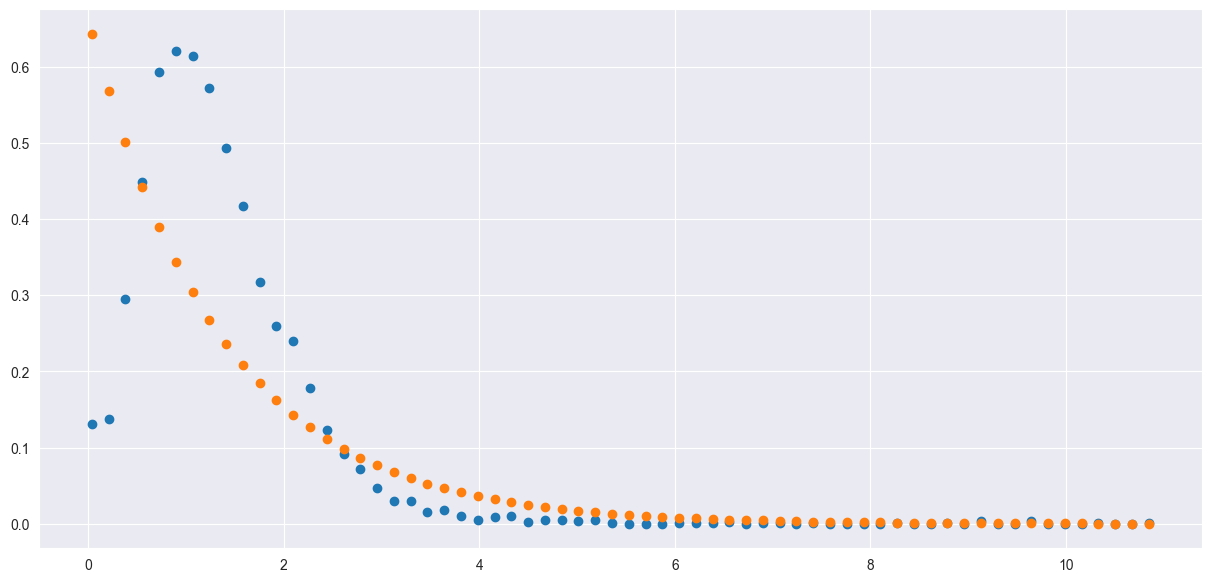

Loc: 0.02762047248571747, scale: 0.7096341126664021
stats: 0.2241274775050553, p-value:3.798026282127385e-186


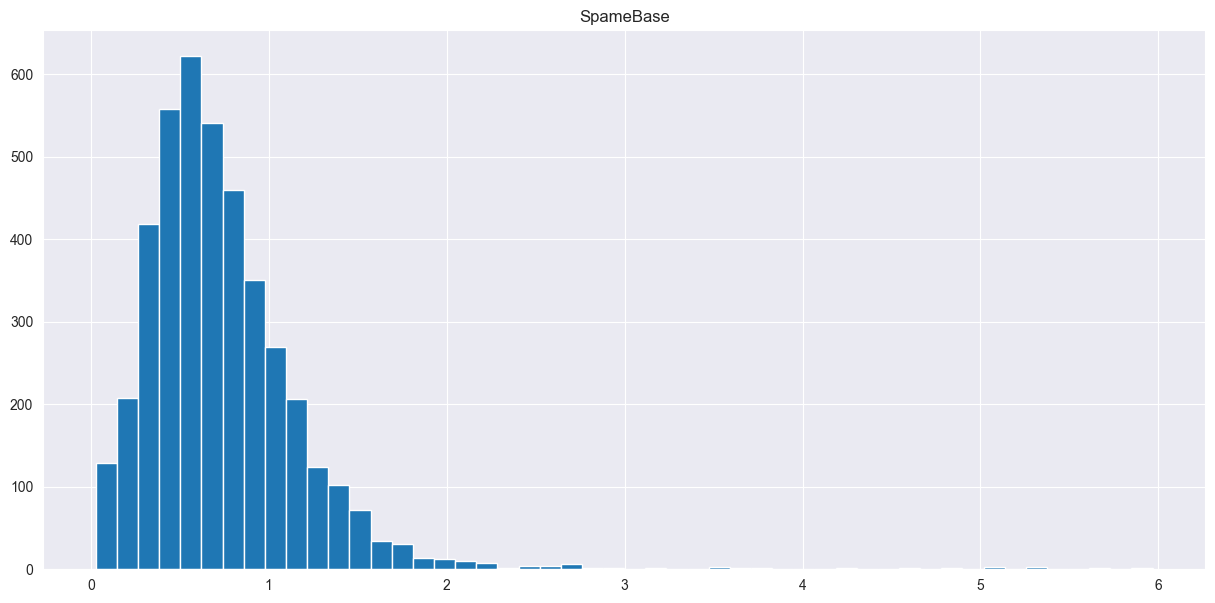

stats: 0.05769860978102537, p-value:1.2905764447406357e-12


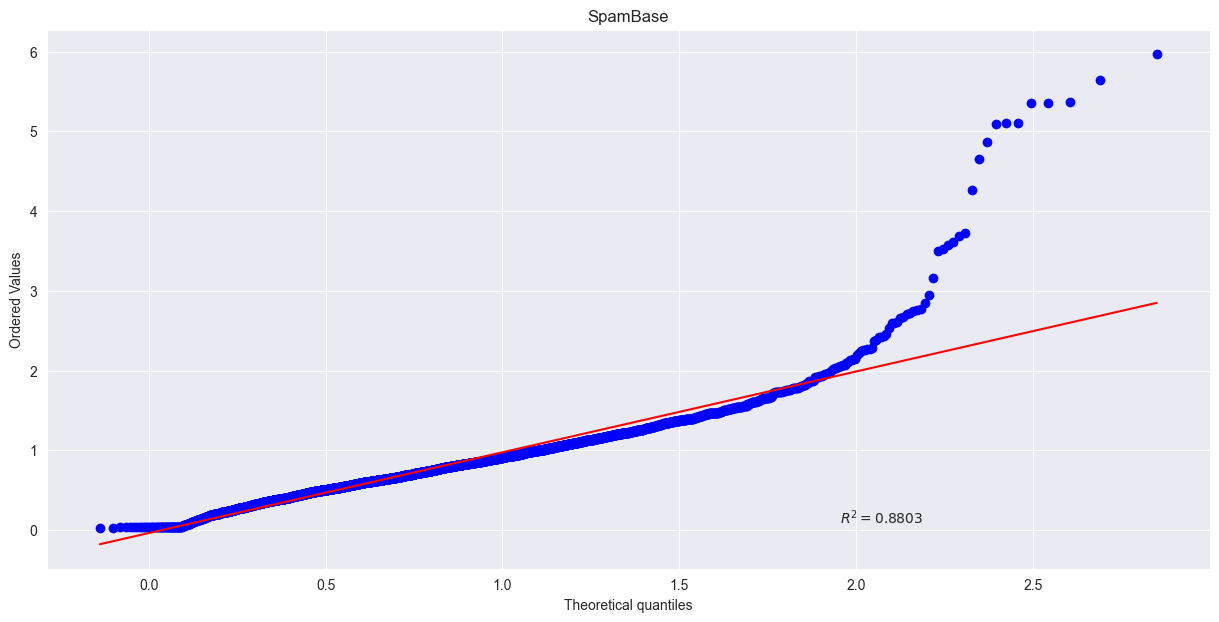

In [466]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,58)
ksTestArr(X,y,58,"SpameBase")
ksTestNorm(X,y,58)
qqPlots(X,y,58,"SpamBase")

0.5293786106805694 21 [0.46533746653515573, 0.5086656333662111, 0.5188812174158094, 0.5220515710863745, 0.5178948851627448, 0.5201493588840355, 0.5207834296181484, 0.5202902634916164, 0.5241651402000846, 0.5278286599971819, 0.5267718754403269, 0.5244469494152459, 0.5281809215161334, 0.5272650415668593, 0.522333380301536, 0.5240242355925039, 0.5263491616175848, 0.5267014231365366, 0.5293081583767789, 0.5293786106805694, 0.5272650415668593, 0.526983232351698, 0.5262082570100043, 0.5286740876426659, 0.5268423277441172, 0.5250105678455685, 0.5222629279977454, 0.5213470480484713, 0.5247287586304072, 0.5210652388333099, 0.5174721713400029, 0.5200084542764549, 0.5157813160490349, 0.513949556150486, 0.5123291531633082, 0.5119064393405663, 0.5130336762012117, 0.5159926729604057, 0.5179653374665351, 0.5144427222770184, 0.5113428209102439, 0.5133859377201634, 0.5114837255178245, 0.5104269409609695, 0.5121882485557279, 0.5091587994927436, 0.5050021135691138, 0.5064816119487108, 0.5076088488093562,

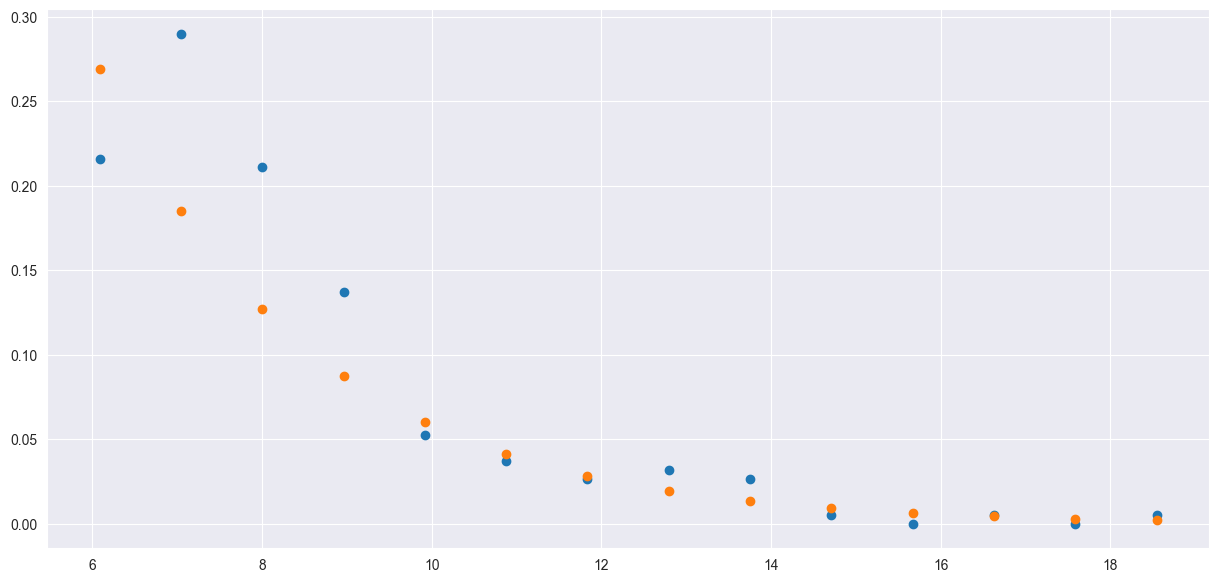

Loc: 3.2269335393966996, scale: 1.3899178405797041
stats: 0.16506394635837807, p-value:3.496263858663608e-05


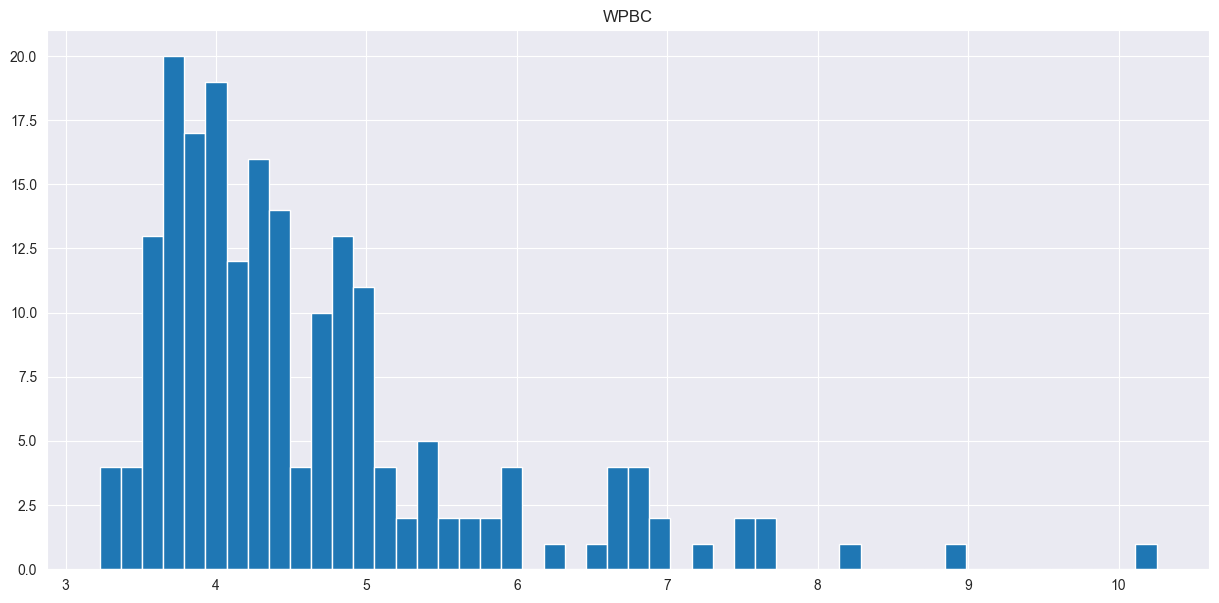

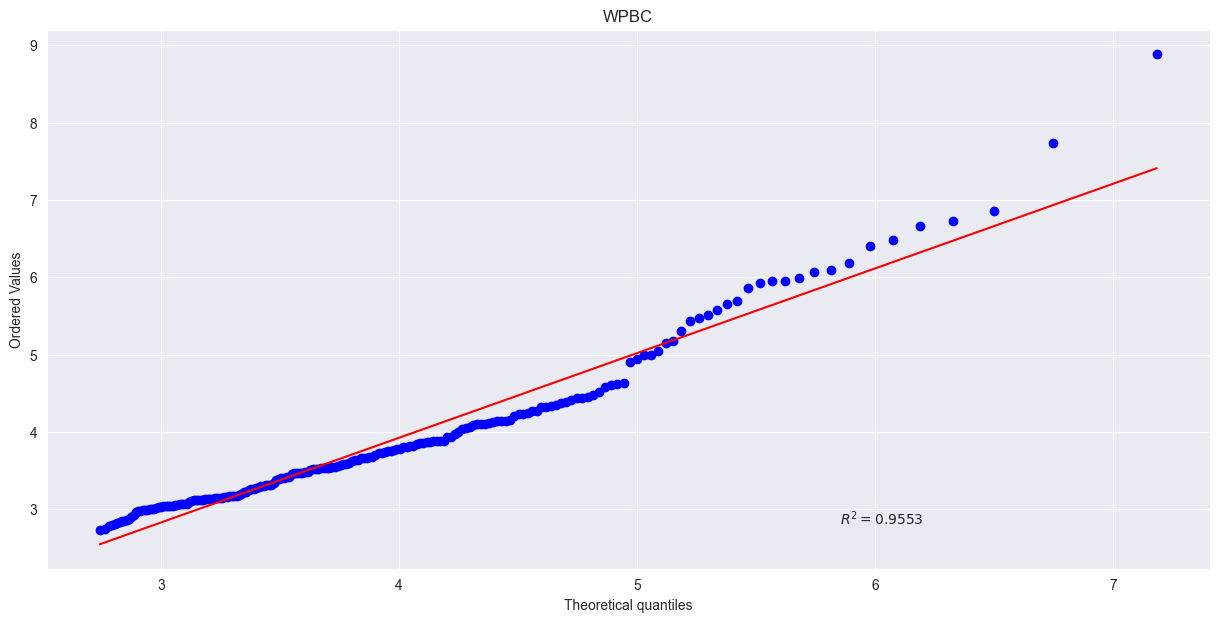

In [467]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 42)
ksTestArr(X,y,42,"WPBC")
qqPlots(X,y,18,"WPBC")

0.698888888888889 66 [0.612, 0.6226944444444446, 0.6175277777777777, 0.623361111111111, 0.6224722222222221, 0.6331666666666665, 0.6310000000000001, 0.6379166666666666, 0.6451111111111112, 0.6440555555555556, 0.6510833333333333, 0.6518333333333334, 0.6524444444444445, 0.6595833333333334, 0.6645277777777778, 0.6629722222222224, 0.6593888888888886, 0.6632500000000001, 0.6567222222222223, 0.6626666666666667, 0.6611111111111112, 0.66375, 0.658611111111111, 0.6548055555555558, 0.665361111111111, 0.6619444444444446, 0.6606944444444446, 0.6622777777777779, 0.661888888888889, 0.66225, 0.660638888888889, 0.6566666666666668, 0.6598055555555555, 0.6641111111111112, 0.6610277777777778, 0.6628333333333334, 0.6613055555555555, 0.6667500000000001, 0.6658055555555557, 0.6664722222222224, 0.6681666666666666, 0.6694444444444445, 0.6678888888888889, 0.6714444444444446, 0.6746944444444445, 0.6737222222222224, 0.6741666666666669, 0.6754722222222221, 0.6809722222222223, 0.6786388888888889, 0.6798611111111111

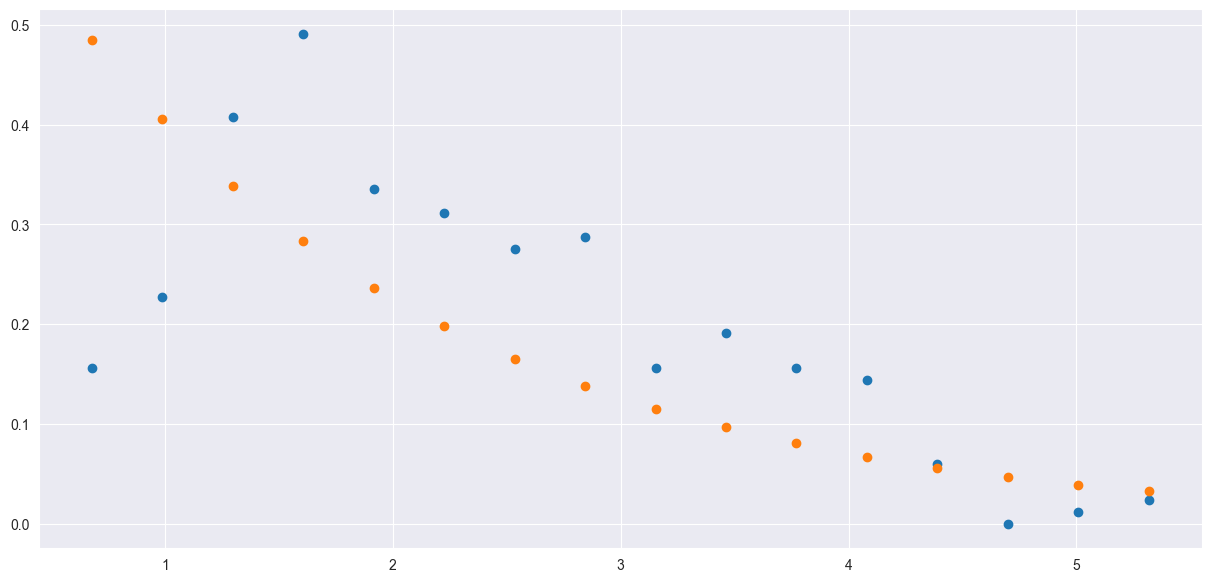

Loc: 0.35466555125658, scale: 0.9591825312361972
stats: 0.20674687844346265, p-value:1.3398180162272476e-10


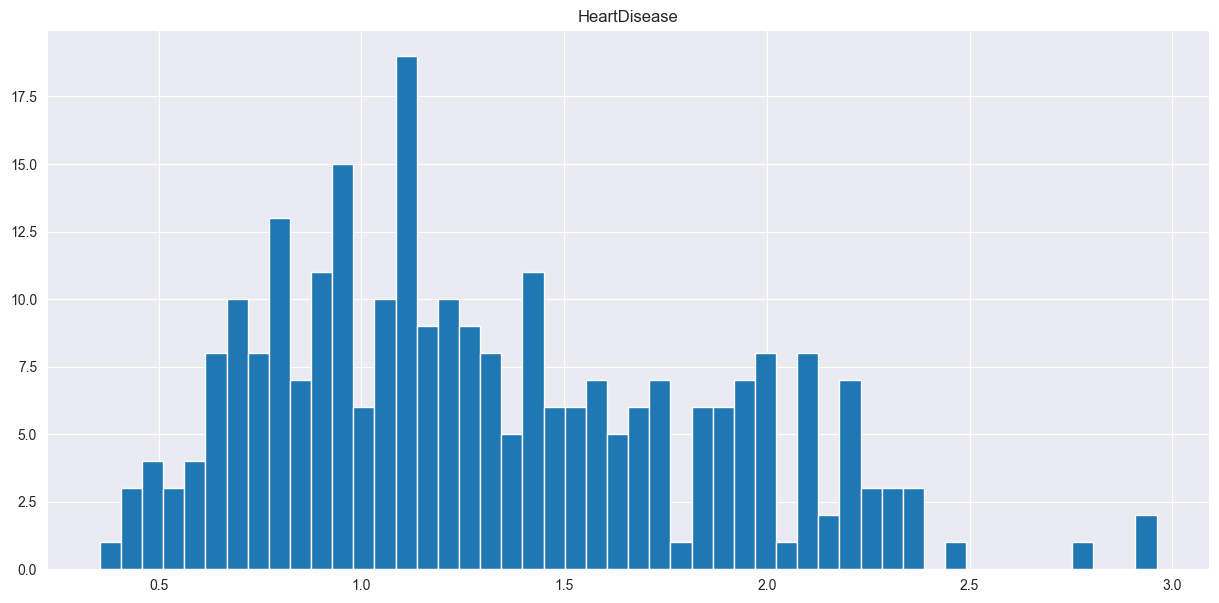

stats: 0.03824674745675072, p-value:0.8099696863247995


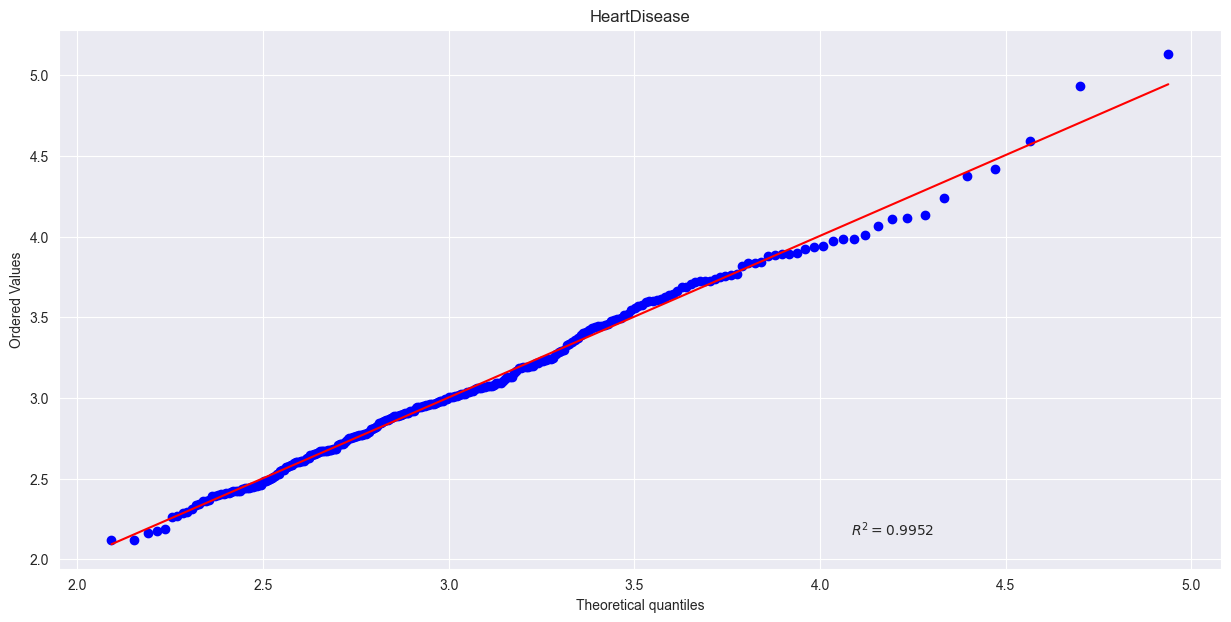

In [468]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 5)
ksTestArr(X,y,5,"HeartDisease")
ksTestNorm(X,y,5)
qqPlots(X,y,69,"HeartDisease")

0.8772357723577238 2 [0.8772357723577238, 0.8387533875338754, 0.8634146341463415, 0.8609756097560978, 0.8655826558265584, 0.8639566395663956, 0.8707317073170734, 0.8710027100271002, 0.8747967479674796, 0.8718157181571815, 0.8720867208672087, 0.8682926829268293, 0.8655826558265582, 0.8653116531165312, 0.8653116531165311, 0.8666666666666667, 0.8634146341463417, 0.8628726287262873, 0.8626016260162601, 0.8615176151761518, 0.853929539295393, 0.8287262872628727, 0.8146341463414635, 0.8070460704607045, 0.8040650406504066, 0.7981029810298103, 0.7910569105691055, 0.7850948509485096, 0.7872628726287263, 0.784010840108401, 0.7859078590785907, 0.7894308943089431, 0.783739837398374, 0.7815718157181571, 0.7804878048780487, 0.7766937669376694, 0.7764227642276423, 0.7840108401084012, 0.7826558265582657, 0.7872628726287263, 0.7907859078590784, 0.783739837398374, 0.7810298102981029, 0.7796747967479676, 0.7794037940379406, 0.784010840108401, 0.7837398373983739, 0.7815718157181573, 0.7872628726287264, 0.7

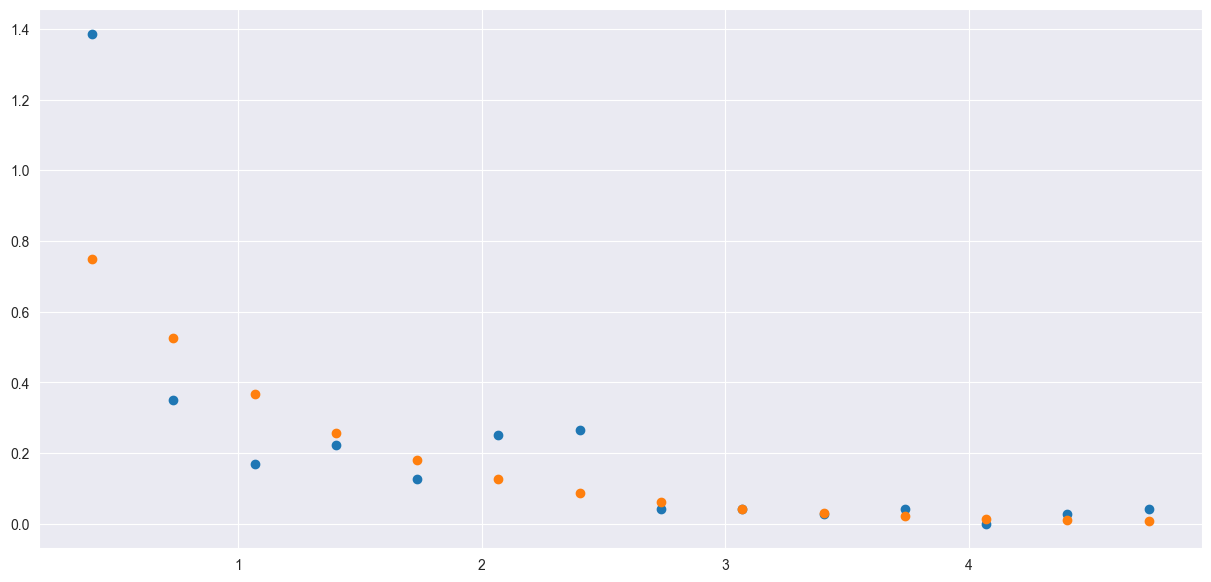

Loc: 0.22940200000000008, scale: 0.5198107710280374
stats: 0.17724610670467655, p-value:2.3678833462672607e-06


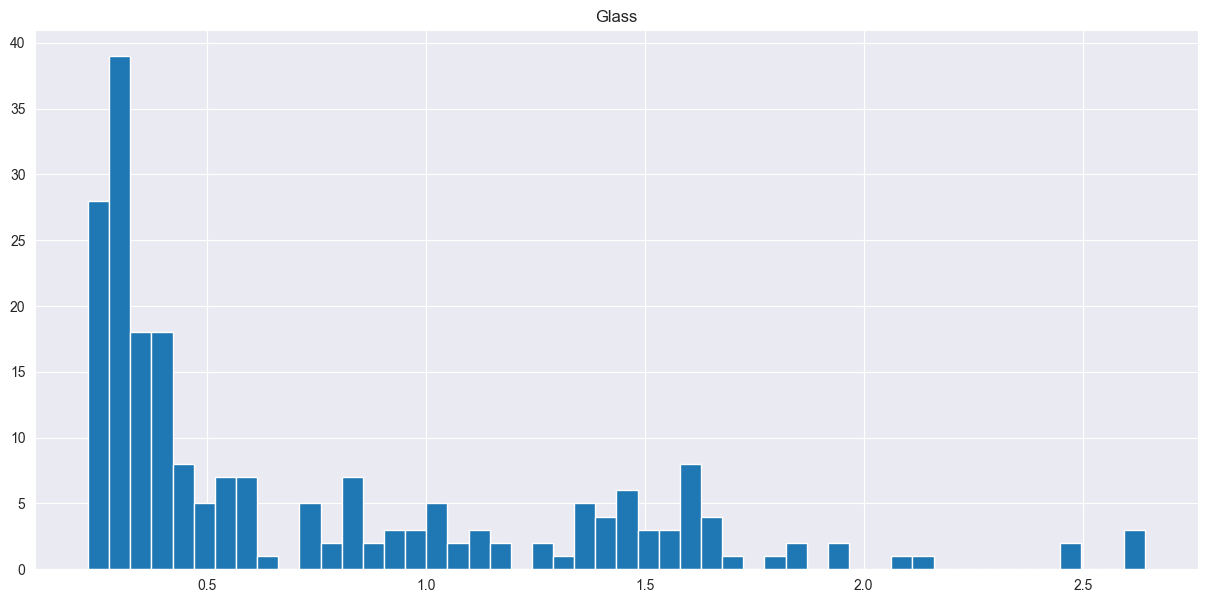

stats: 0.2780273979900063, p-value:4.05905368829843e-15


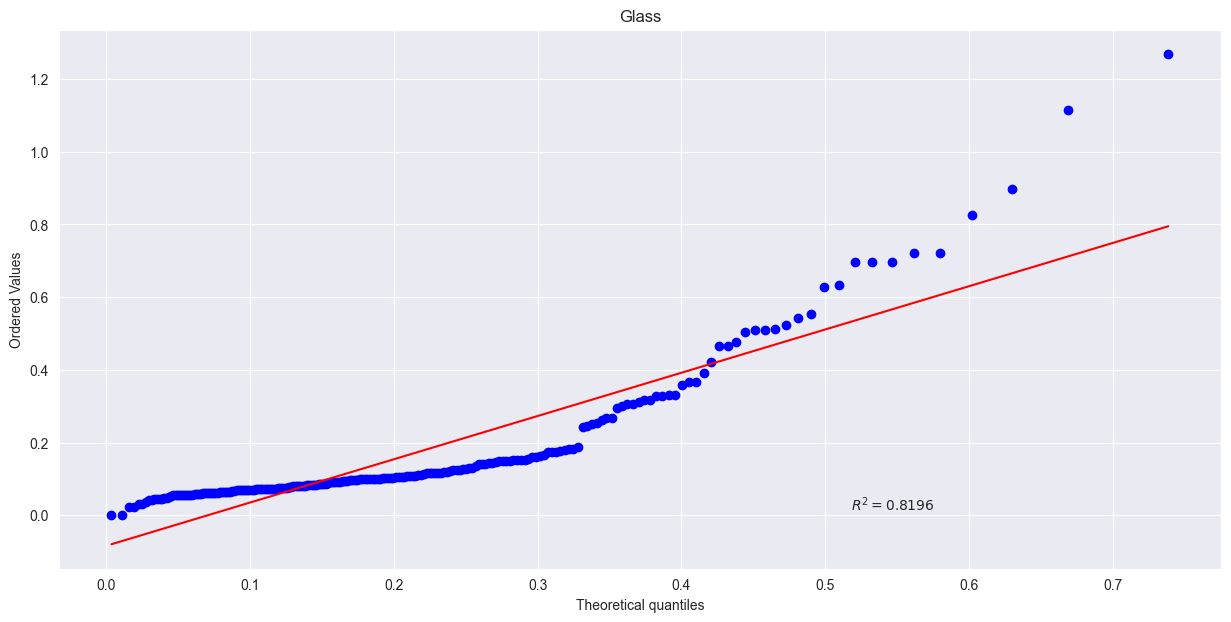

In [469]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 63)
ksTestArr(X,y,63,"Glass")
ksTestNorm(X,y,63)
qqPlots(X,y,2,"Glass")

0.7853042479908152 26 [0.6165327210103331, 0.6119402985074628, 0.653272101033295, 0.6659012629161883, 0.672215843857635, 0.677382319173364, 0.7020665901262917, 0.714121699196326, 0.7037887485648681, 0.7215843857634902, 0.7181400688863376, 0.7244546498277842, 0.7256027554535018, 0.7296211251435131, 0.7502870264064293, 0.7485648679678532, 0.7525832376578645, 0.7525832376578645, 0.7554535017221585, 0.7588978185993112, 0.7680826636050516, 0.7709529276693455, 0.7761194029850746, 0.7853042479908151, 0.7853042479908152, 0.7824339839265212, 0.7709529276693455, 0.7738231917336396, 0.7680826636050516, 0.7726750861079219, 0.7732491389207807, 0.7784156142365097, 0.7784156142365097, 0.7772675086107921, 0.7784156142365097, 0.769804822043628, 0.7743972445464982, 0.7766934557979334, 0.7766934557979334, 0.7732491389207807, 0.7680826636050516, 0.7594718714121699, 0.7583237657864522, 0.7560275545350171, 0.7623421354764637, 0.758897818599311, 0.7606199770378874, 0.7491389207807119, 0.7405281285878301, 0.7

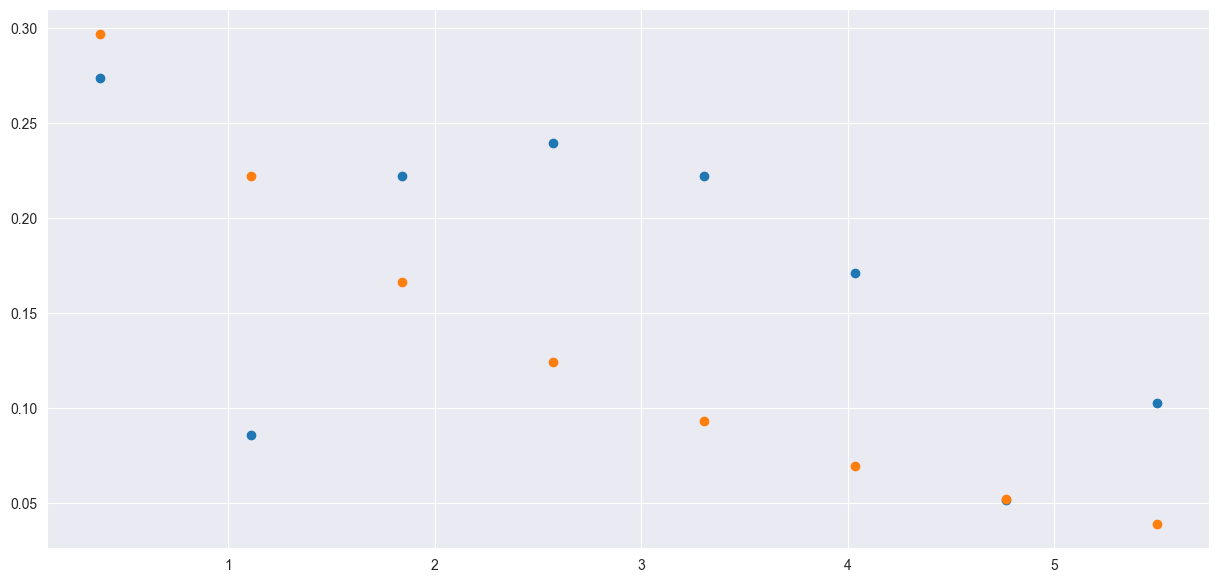

Loc: 0.2510598708317958, scale: 1.6807648650185305
stats: 0.2301096297416857, p-value:0.0003311234187659161


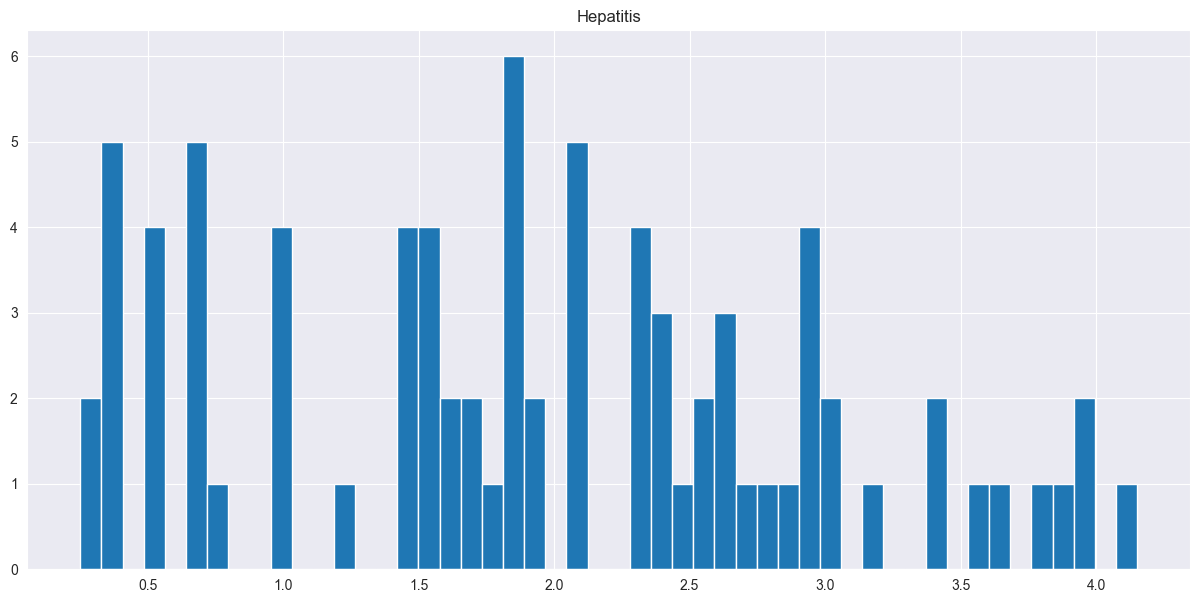

stats: 0.08858876880967925, p-value:0.5275666193224898


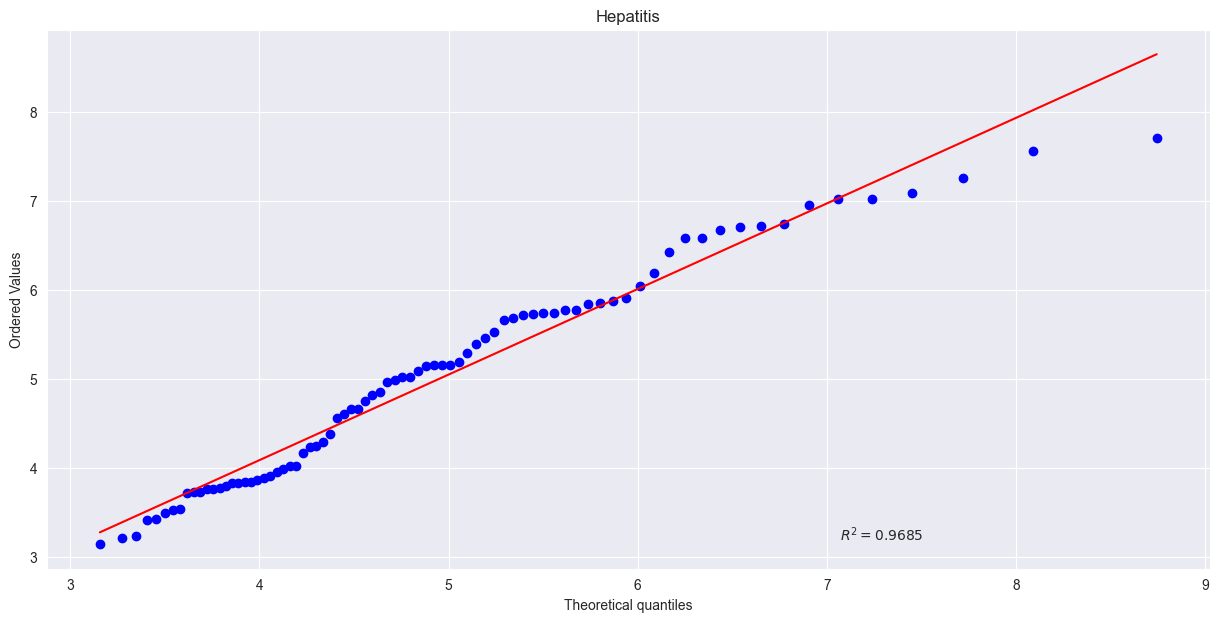

In [470]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 2)
ksTestArr(X,y,2,"Hepatitis")
ksTestNorm(X,y,2)
qqPlots(X,y,25,"Hepatitis")

0.7352686567164178 68 [0.6770522388059701, 0.6938097014925373, 0.705973880597015, 0.7074291044776121, 0.712723880597015, 0.7148694029850746, 0.7190746268656717, 0.720973880597015, 0.7207164179104478, 0.7202126865671641, 0.7196679104477611, 0.721294776119403, 0.7219589552238806, 0.7233917910447761, 0.7219253731343284, 0.7220783582089553, 0.7231268656716416, 0.7239104477611941, 0.7237947761194029, 0.7267164179104479, 0.7270783582089553, 0.7259477611940297, 0.7263470149253732, 0.7265858208955224, 0.7275111940298508, 0.7277873134328359, 0.727742537313433, 0.7272164179104477, 0.7270932835820896, 0.7279925373134328, 0.7290261194029851, 0.7295858208955223, 0.7288992537313433, 0.7297500000000001, 0.7291380597014925, 0.7285261194029852, 0.7285671641791047, 0.7283880597014926, 0.7287201492537313, 0.7301716417910447, 0.7300858208955224, 0.7297947761194031, 0.7306156716417912, 0.7308358208955226, 0.7318246268656716, 0.7309029850746269, 0.7312425373134329, 0.7308619402985074, 0.7316604477611939, 0.

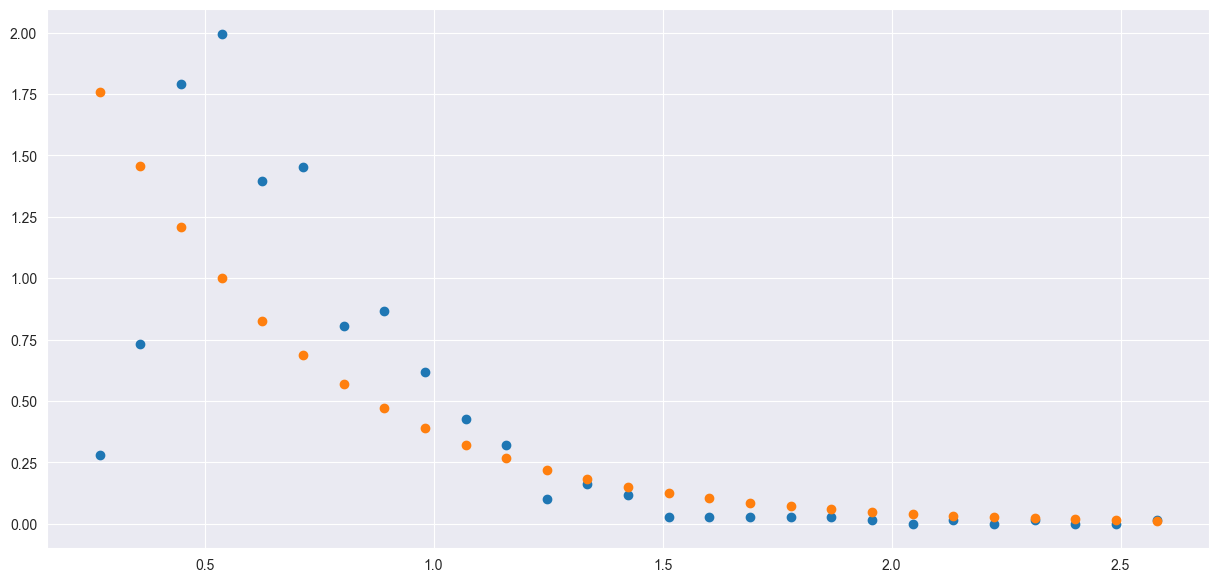

Loc: 0.15109881131516203, scale: 0.2486891441926765
stats: 0.2301952114942487, p-value:2.9315664344609153e-36


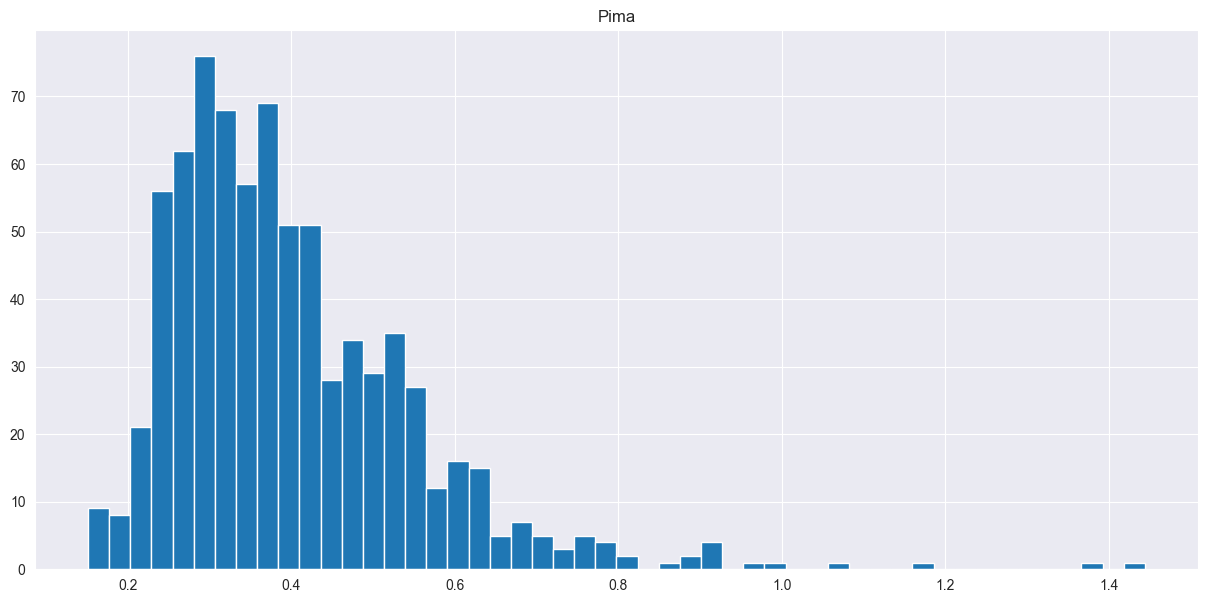

stats: 0.05417093196786893, p-value:0.021237031780847827


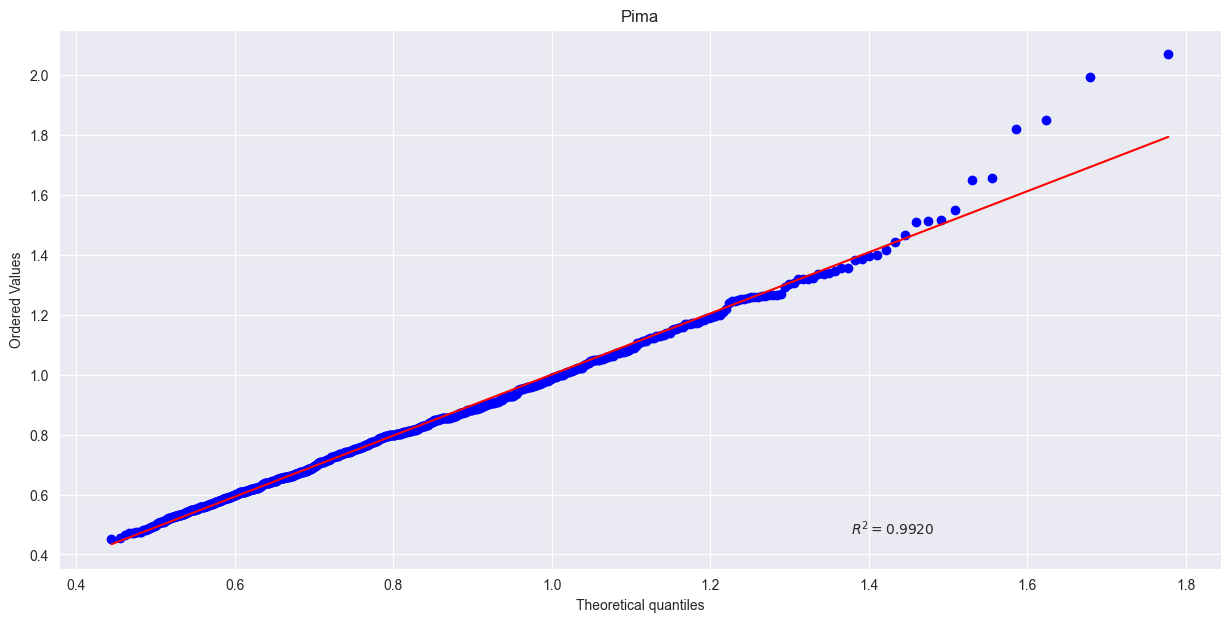

In [477]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)
ksTestArr(X,y,3,"Pima")
ksTestNorm(X,y,3)
qqPlots(X,y,68,"Pima")

0.9826944557270512 9 [0.9265637692932575, 0.9744237408610884, 0.9747537571080422, 0.9782696994313566, 0.9788281884646629, 0.9799045491470351, 0.9815343216896831, 0.9826944557270512, 0.9826132209585703, 0.9818034118602763, 0.9819861900893583, 0.9821385052802599, 0.9819303411860277, 0.9810418359057678, 0.980808285946385, 0.9806813566206336, 0.9798030056864339, 0.9787875710804224, 0.9784626320064987, 0.9778686027619821, 0.9767313160032494, 0.9758859666937448, 0.9762109057676686, 0.9756498781478473, 0.9755051787164907, 0.9753046303818034, 0.9754315597075548, 0.9752690901705929, 0.9751472380178715, 0.975360479285134, 0.9757488830219334, 0.9755077173030057, 0.9755229488220958, 0.9756676482534524, 0.9756752640129976, 0.9752386271324128, 0.9750177701056052, 0.9737307067424857, 0.9741470349309506, 0.9742282696994314, 0.9741774979691307, 0.9742333468724615, 0.9743501218521526, 0.9741318034118601, 0.9742384240454914, 0.9743247359870025, 0.9732356823720553, 0.9731392160844843, 0.972865048740861, 0

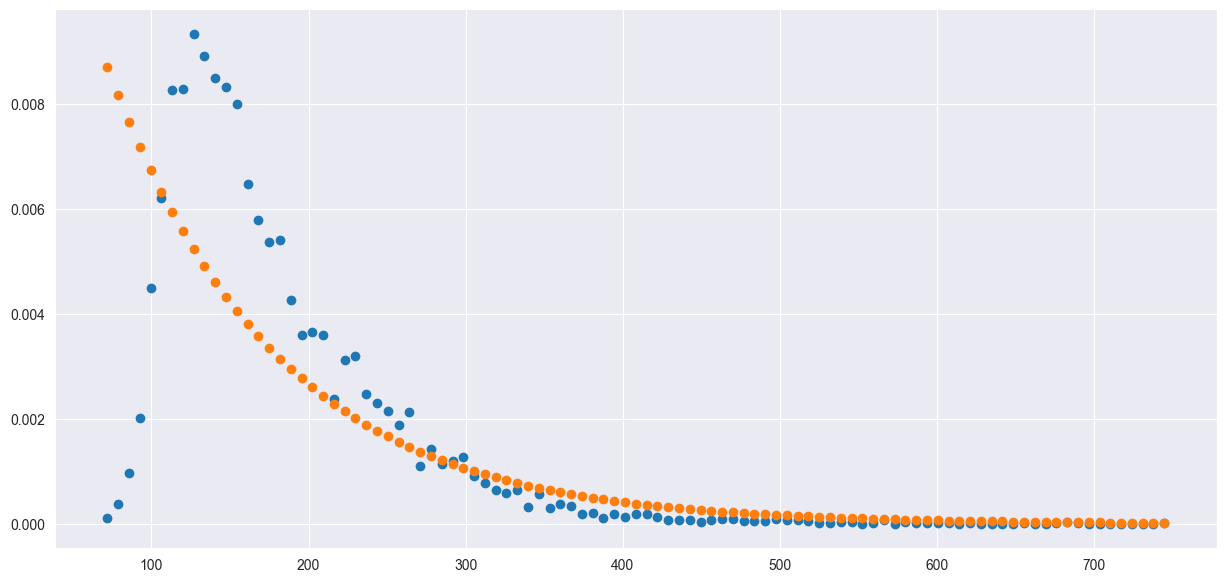

Loc: 40.0, scale: 56.83988650182408
stats: 0.21525579311678084, p-value:0.0


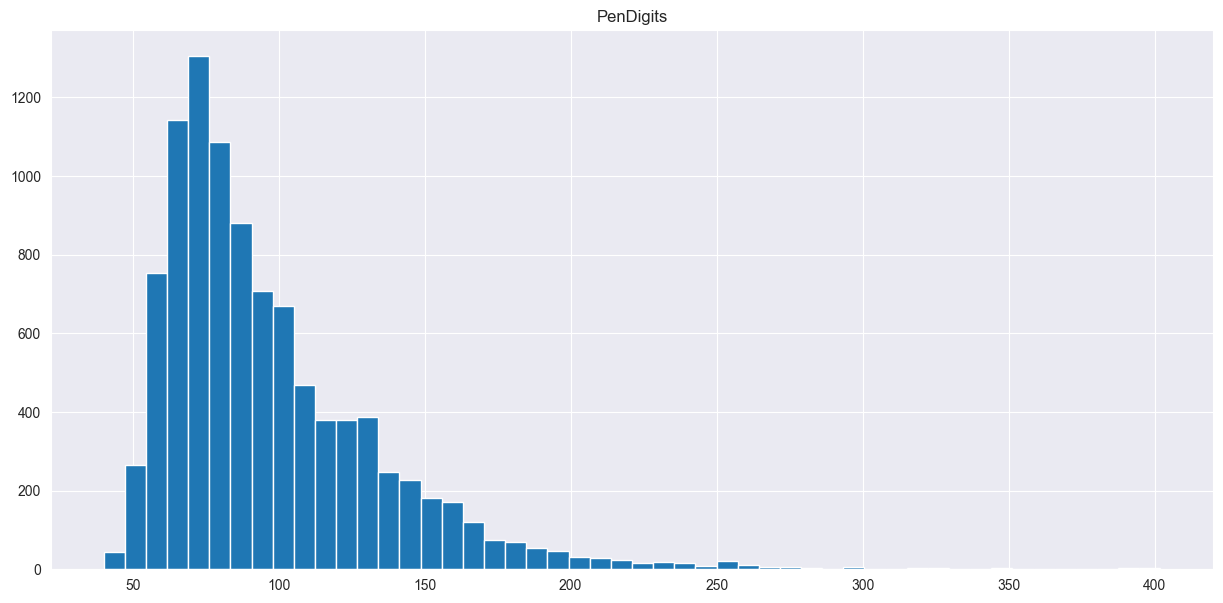

stats: 0.07281902046186317, p-value:5.98839687412291e-46


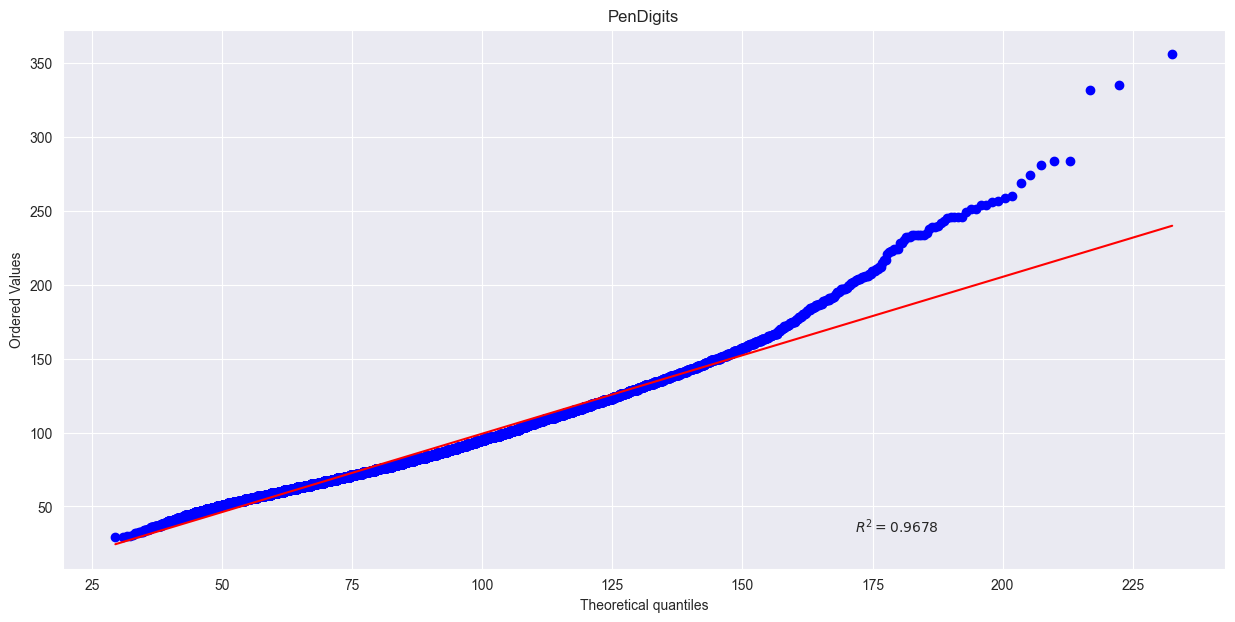

In [478]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 20)
ksTestArr(X,y,20,"PenDigits")
ksTestNorm(X,y,20)
qqPlots(X,y,9,"PenDigits")

0.8844383719257876 43 [0.8096180555555555, 0.7915695981362842, 0.805989847715736, 0.8057352941176471, 0.8003663003663004, 0.7622205380826071, 0.7412087912087912, 0.7606338615512928, 0.7587250712250712, 0.7201475334255416, 0.7343629343629343, 0.6876006441223833, 0.67439293598234, 0.7025723472668809, 0.7420560747663552, 0.7484939759036143, 0.7564732874467388, 0.7977729885057472, 0.7886776145203112, 0.7877984084880636, 0.772172236503856, 0.7933059307105108, 0.8051378446115286, 0.8054862842892768, 0.8298195631528963, 0.8368501822367159, 0.8419856006062904, 0.8424447174447175, 0.8417487684729066, 0.8566831683168318, 0.8534231200897868, 0.8612163698370594, 0.86003861003861, 0.8415233415233416, 0.8409327323162274, 0.8684451219512195, 0.8588377723970946, 0.8761326860841422, 0.8482854494902687, 0.8571285140562249, 0.872746185852982, 0.8844383719257876, 0.867718446601942, 0.87260162601626, 0.8436754176610979, 0.8384615384615386, 0.843571296808707, 0.8543756485645106, 0.8511615811373094, 0.849506

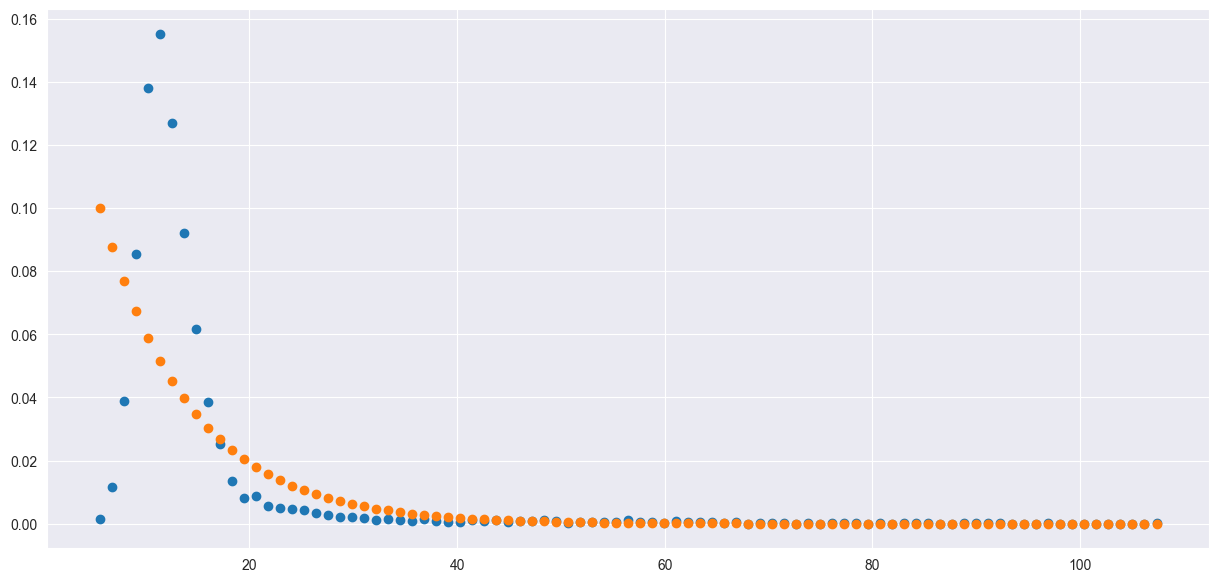

In [473]:
X, y = setupDf("clusters/artificial/cluto-t4-8k.arff")
endResults = outputResultsArt(X, y,checkValue=6)
printResults(endResults)
goodnessOfFit(X, y, 11)

0.9067467652495378 34 [0.7380865102639296, 0.7628641917293233, 0.8281431615652848, 0.8128431372549019, 0.794856298683857, 0.7783643371878666, 0.7803330689928629, 0.8046591677423319, 0.8041417165668662, 0.7826377952755905, 0.8048917102315162, 0.804927863723275, 0.7864125604818801, 0.7432626896912612, 0.8610167022722858, 0.8514399856895831, 0.8641670539033457, 0.8747993579454254, 0.8651227891589259, 0.8610939960293013, 0.8705400372439478, 0.8652052238805971, 0.8710118138712529, 0.8513207175241474, 0.8660883708322038, 0.8498075865860363, 0.8389303482587065, 0.8561601000625391, 0.8571428571428571, 0.8701350732600733, 0.8827854671280277, 0.8948825014565934, 0.9067467652495378, 0.8826203208556149, 0.8946754257066297, 0.8930171277997365, 0.8907673523058137, 0.9059547244094487, 0.8935340690978887, 0.8859582542694495, 0.8799012887304634, 0.8795825179386823, 0.8858935466078324, 0.8874368874368874, 0.8831874274865521, 0.8818072024593764, 0.8793211422845691, 0.8815233598409542, 0.8729292168674697,

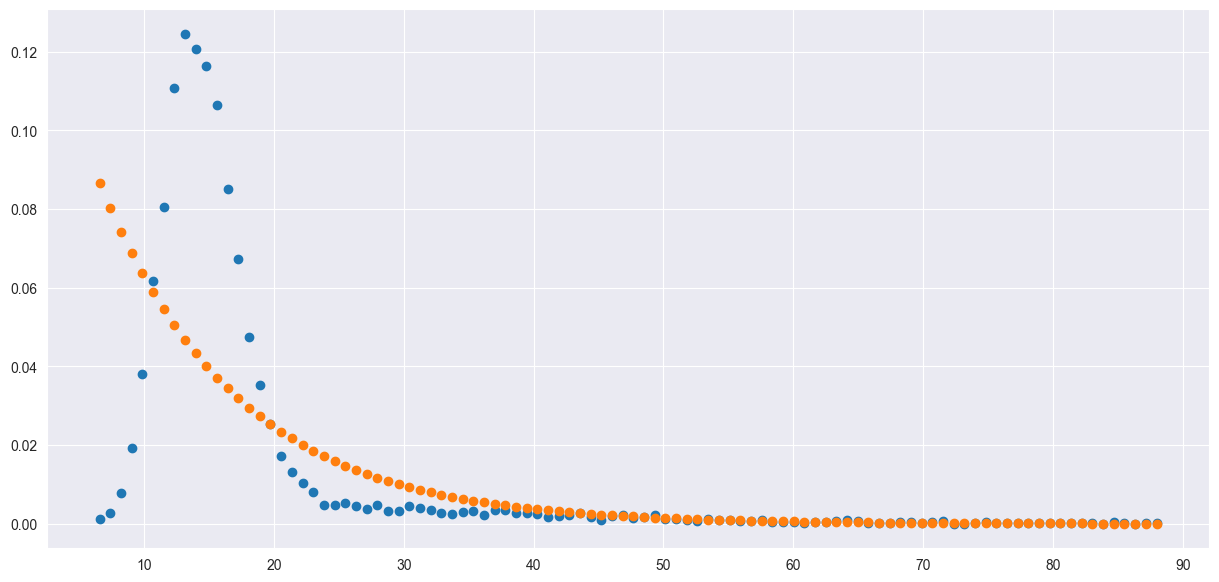

In [474]:
X, y = setupDf("clusters/artificial/cluto-t7-10k.arff")
endResults = outputResultsArt(X, y,checkValue=9)
printResults(endResults)
goodnessOfFit(X, y, 11)

0.8848314606741573 12 [0.766794437073075, 0.8235150925024342, 0.8731590574374078, 0.8405405405405405, 0.8777915632754342, 0.8376623376623376, 0.8267357512953368, 0.8365193150139387, 0.8785607196401799, 0.8783783783783785, 0.8848314606741573, 0.8598078010175241, 0.8618646978021978, 0.8697423266388783, 0.8689236111111112, 0.8671296296296296, 0.8726604278074866, 0.8664283392915177, 0.8758253851797506, 0.8755623100303951, 0.8711153682418051, 0.8653382761816496, 0.8554750402576489, 0.8559947299077733, 0.8530864197530863, 0.8642354010452169, 0.8510309955345415, 0.8567603748326639, 0.8617563035647747, 0.8710007047216349, 0.8665859088528025, 0.8576478982874934, 0.8608062330623305, 0.8495250938086303, 0.857002360346184, 0.8561035981646945, 0.8553121954016396, 0.8638946596602713, 0.8588431395484851, 0.8619165487977369, 0.8595254669915304, 0.8671700078104662, 0.8743276159545317, 0.8809523809523812, 0.8705216685273521, 0.8641010661603623, 0.8714730538922156, 0.8628568327363507, 0.8637376409970757,

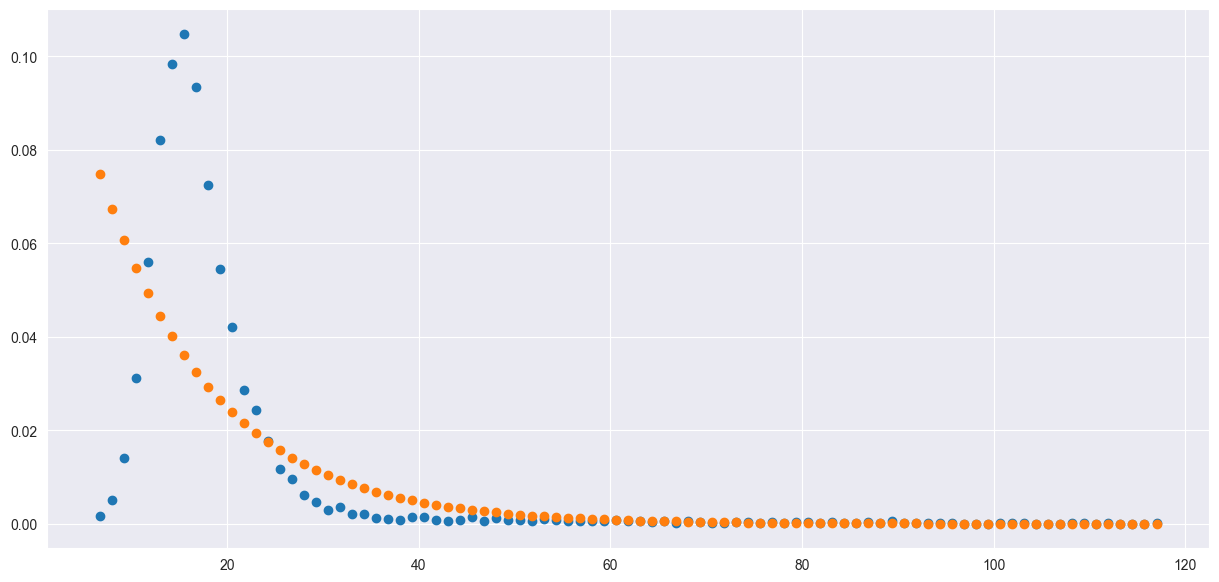

In [475]:
X, y = setupDf("clusters/artificial/cluto-t8-8k.arff")
endResults = outputResultsArt(X, y,checkValue=8)
printResults(endResults)
goodnessOfFit(X, y, 11)